# Posture Detection - Full Pipeline

## Overview
This notebook covers the full machine learning pipeline for real-time posture classification using IMU data collected from two ESP32 nodes.

## Hardware
- 3× ESP32 WROOM-32 (1 as a master)
- 2× MPU6050 (accelerometer + gyroscope)
- Node **lombar**: lower back
- Node **esterno**: chest

## Data Collection
- Sampling rate: 50Hz (50 samples per second)
- Session duration: ~20 seconds per session
- 5 sessions per class

## Classes
| Label | Description |
|-------|-------------|
| `seated_good` | Correct seated posture |
| `seated_bad_front` | Leaning forward (seated) |
| `seated_bad_back` | Leaning back (seated) |
| `standing_good` | Correct standing posture |
| `standing_bad_front` | Leaning forward (standing) |

## Pipeline
1. Imports & Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model Training
6. Export to TFLite

## 1. Imports and Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", None)

print(f"TensorFlow version: {tf.__version__}")
print("Libraries loaded.")

TensorFlow version: 2.21.0
Libraries loaded.


## Load Data

In [3]:
dfs = []
base = "."

VALID_LABELS = ["seated_bad_back", "seated_bad_front", "seated_good", "standing_bad_front", "standing_good"]

for root, dirs, files in os.walk(base):
    dirs[:] = [d for d in dirs if d not in [".venv", ".git", "__pycache__"]]
    
    for file in files:
        if file.endswith(".csv"):
            path = os.path.join(root, file)
            label = os.path.normpath(root).replace(os.path.normpath(base), "").strip(os.sep)
            label = label.replace(os.sep, "_")
            
            if label not in VALID_LABELS:
                continue
                
            df = pd.read_csv(path)
            df["label"] = label
            dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"Total rows:    {data.shape[0]}")
print(f"Total columns: {data.shape[1]}")
print(f"\nLabels found:\n{data['label'].value_counts()}")
data.head()

Total rows:    49565
Total columns: 10

Labels found:
label
standing_bad_front    10743
seated_good           10236
seated_bad_front       9682
seated_bad_back        9644
standing_good          9260
Name: count, dtype: int64


,timestamp,node,ax,ay,az,gx,gy,gz,t_ms,label
0,2026-05-19 20:10:00,lombar,9524,-1744,-12920,-277,-243,417,979809,seated_bad_back
1,2026-05-19 20:10:00,esterno,3236,10400,11448,-236,-331,231,322376,seated_bad_back
2,2026-05-19 20:10:00,lombar,9488,-1680,-12908,-324,-189,439,979831,seated_bad_back
3,2026-05-19 20:10:00,esterno,2944,10064,11336,-15,-224,90,322398,seated_bad_back
4,2026-05-19 20:10:00,lombar,9536,-1816,-13124,-335,-296,382,979853,seated_bad_back


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

Before any preprocessing, we examine how samples are distributed across the five posture classes. 
An imbalanced dataset can bias the model toward majority classes, leading to poor performance 
on underrepresented ones. Understanding the distribution early allows us to decide whether 
corrective measures, such as class weighting or oversampling, are needed.

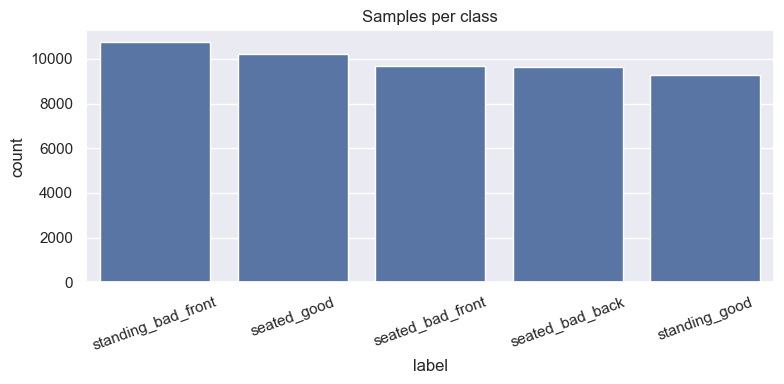

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x="label", order=data["label"].value_counts().index)
plt.xticks(rotation=20)
plt.title("Samples per class")
plt.tight_layout()
plt.show()

The dataset contains **49,565 samples** across 5 classes. The distribution is mildly imbalanced: 
`standing_bad_front` is the largest class (~10,743 samples) while `standing_good` is the smallest 
(~9,260 samples), a difference of roughly 16%. This level of imbalance is not severe enough to 
require oversampling. Instead, class weights will be applied during training to compensate.

### 3.2 Data Quality

A clean dataset is a prerequisite for a reliable model. Here we check for null values, 
duplicate rows, data types, and node balance. Any issues found at this stage must be 
resolved before preprocessing.

In [5]:
print("Null values:\n", data.isnull().sum())
print(f"\nDuplicate rows: {data.duplicated().sum()}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nNode distribution:\n{data['node'].value_counts()}")

Null values:
 timestamp    0
node         0
ax           0
ay           0
az           0
gx           0
gy           0
gz           0
t_ms         0
label        0
dtype: int64

Duplicate rows: 0

Data types:
timestamp    object
node         object
ax            int64
ay            int64
az            int64
gx            int64
gy            int64
gz            int64
t_ms          int64
label        object
dtype: object

Node distribution:
node
esterno    24784
lombar     24781
Name: count, dtype: int64


The dataset is clean: no null values, no duplicate rows. Both nodes are nearly perfectly 
balanced (esterno: 24,784 / lombar: 24,781), confirming both ESP32s sampled consistently 
throughout the collection sessions. The `timestamp` column is stored as a string object 
and will be converted to datetime in the preprocessing step.

### 3.3 Signal Visualization per Class

To verify that the sensors are producing meaningful data, we plot a 100-sample window 
of raw IMU readings for each node on the `seated_good` class. This allows us to visually 
inspect signal stability, noise levels, and sensor orientation

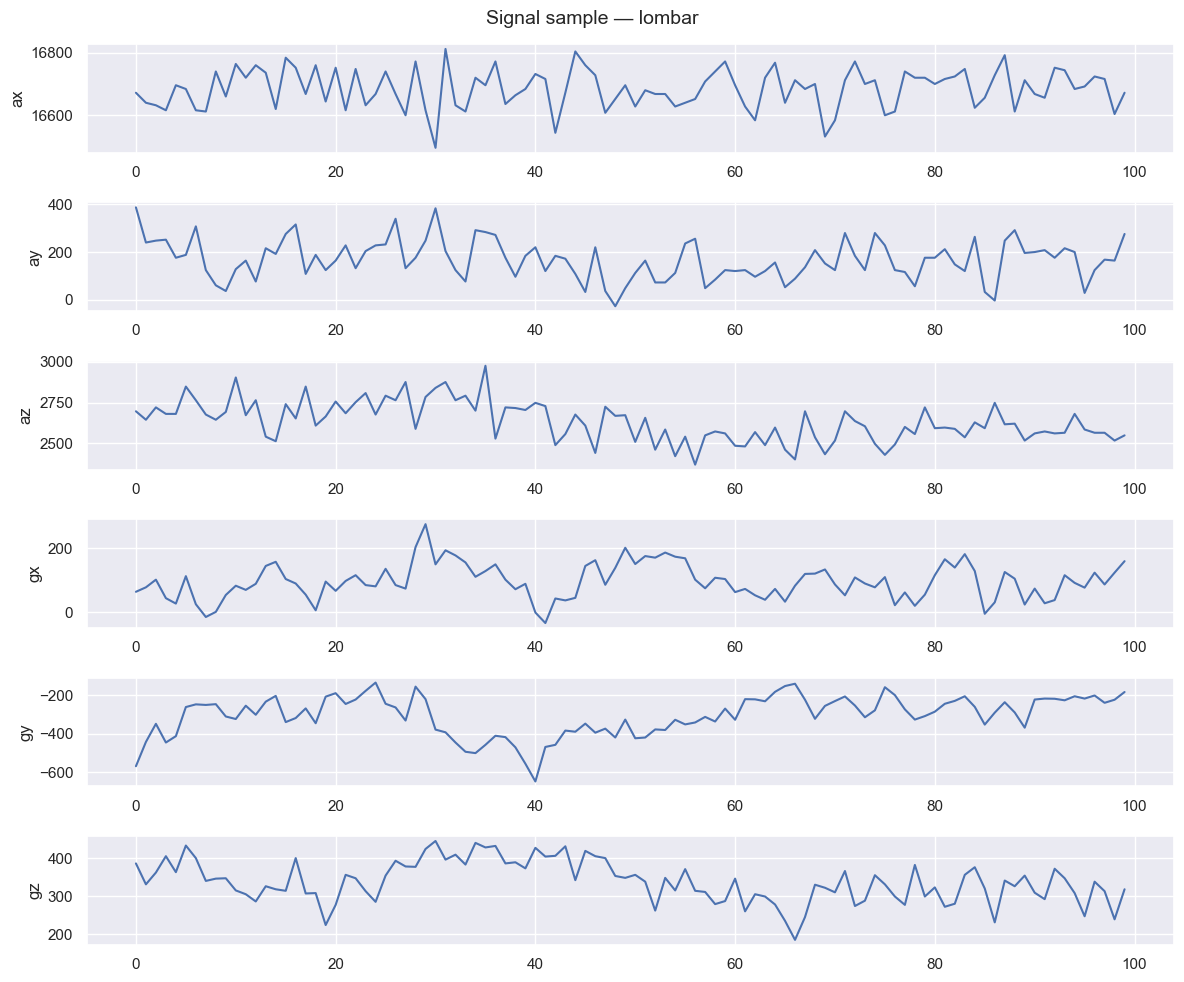

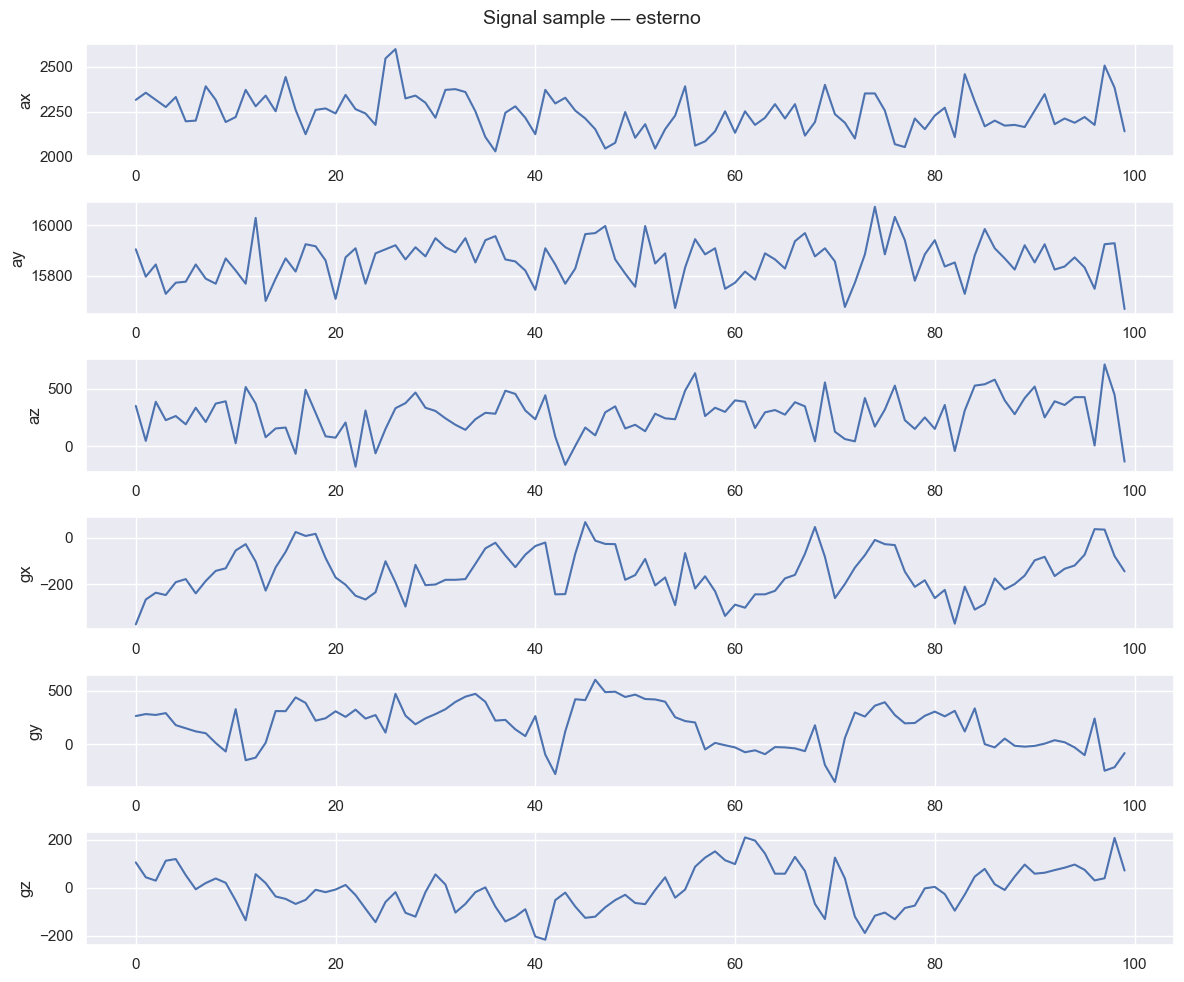

In [6]:
features = ["ax", "ay", "az", "gx", "gy", "gz"]
nodes = ["lombar", "esterno"]

for node in nodes:
    fig, axes = plt.subplots(len(features), 1, figsize=(12, 10), sharex=False)
    fig.suptitle(f"Signal sample — {node}", fontsize=14)
    
    sample = data[(data["node"] == node) & (data["label"] == "seated_good")].head(100)
    
    for i, feat in enumerate(features):
        axes[i].plot(sample[feat].values)
        axes[i].set_ylabel(feat)
    
    plt.tight_layout()
    plt.show()

Both nodes produce stable signals consistent with a person holding a static posture. 

On the **lombar** node, `ax` is dominant (~16,700), indicating the sensor's X axis is 
closely aligned with gravity, expected given the sensor's orientation on the lower back. 
The gyroscope readings show low-amplitude noise with no large spikes, confirming the 
person was still during data collection.

On the **esterno** node, `ay` is dominant (~15,800), reflecting a different sensor 
orientation on the chest. Again, gyroscope readings are stable with no anomalous dropouts 
or sudden jumps that would indicate a loose connection or sensor failure.

Both signals are suitable for windowing and model training without additional filtering.

### 3.4 Node Synchronization

Since both ESP32 nodes operate independently with separate clocks, their samples are not 
perfectly aligned in time. Before merging lombar and esterno into a single feature vector, 
we verify that both nodes are capturing data at approximately the same rate within each class. 

A large difference in sample count between nodes for the same class would indicate dropped 
packets or connectivity issues during data collection, which would complicate the merge step.

In [7]:
lombar  = data[data["node"] == "lombar"].copy()
esterno = data[data["node"] == "esterno"].copy()

print(f"{'Label':25s} | {'Lombar':>8} | {'Esterno':>8} | {'Diff':>6}")
print("-" * 55)
for label in sorted(data["label"].unique()):
    l = len(lombar[lombar["label"] == label])
    e = len(esterno[esterno["label"] == label])
    print(f"{label:25s} | {l:>8} | {e:>8} | {abs(l-e):>6}")

Label                     |   Lombar |  Esterno |   Diff
-------------------------------------------------------
seated_bad_back           |     4822 |     4822 |      0
seated_bad_front          |     4841 |     4841 |      0
seated_good               |     5117 |     5119 |      2
standing_bad_front        |     5372 |     5371 |      1
standing_good             |     4629 |     4631 |      2


The results confirm excellent synchronization between both nodes across all classes. 
The maximum difference between lombar and esterno sample counts is **2 samples**, 
negligible at 50Hz, corresponding to less than 40 milliseconds of drift.

This means the nearest-neighbor merge in the preprocessing step will produce 
near-perfect pairs with minimal temporal mismatch, and no samples need to be discarded.

The dataset is ready for preprocessing.

## 4. Preprocessing

Raw data from two independent nodes must be transformed into a format suitable for model training. 
This section covers four steps:

1. **Merge** — pair each lombar sample with its closest esterno sample by time
2. **Windowing** — segment the continuous signal into fixed-length windows
3. **Normalization** — scale features to a common range
4. **Encoding** — convert string labels to integers